# Morphological HMM Tagger — Demo Notebook

Interactive walkthrough of the first-order HMM POS tagger: corpus loading, exploratory data checks, the induced out-of-vocabulary (OOV) split, the suffix-based morphological prior, and a benchmark comparison of four OOV handling strategies (baseline uniform, Add-α smoothing, Good-Turing, and the proposed morphological prior).

In [2]:
%matplotlib inline

import sys
from pathlib import Path

import pandas as pd

# Ensure the workspace root (parent of this package) is importable when running the notebook in place.
workspace_root = Path.cwd().parent
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from morphological_hmm_tagger.data_loader import (
    BOS_TOKEN,
    EOS_TOKEN,
    CorpusDataLoader,
    get_vocabulary_stats,
)
from morphological_hmm_tagger.hmm_core import FirstOrderHMMTagger
from morphological_hmm_tagger.morphological import SuffixMorphologyModel
from morphological_hmm_tagger.evaluator import (
    benchmark_all,
    results_to_frame,
    sentence_tags,
    sentence_words,
)
from morphological_hmm_tagger.visualizer import plot_benchmark_results, results_to_latex

pd.set_option("display.max_columns", None)

## Load the Brown Corpus

Download (if needed) and parse the NLTK Brown corpus with the universal tagset. Sentences are returned as lists of `(word, tag)` pairs padded with `<BOS>`/`<EOS>` boundary tokens.

In [3]:
loader = CorpusDataLoader(dataset_name="brown", universal_tagset=True)
sentences = loader.load_corpus()

print(f"Total sentences: {len(sentences):,}")
print("First sentence (with boundary tokens):")
print(sentences[0])

Total sentences: 57,340
First sentence (with boundary tokens):
[('<BOS>', '<BOS_TAG>'), ('The', 'DET'), ('Fulton', 'NOUN'), ('County', 'NOUN'), ('Grand', 'ADJ'), ('Jury', 'NOUN'), ('said', 'VERB'), ('Friday', 'NOUN'), ('an', 'DET'), ('investigation', 'NOUN'), ('of', 'ADP'), ("Atlanta's", 'NOUN'), ('recent', 'ADJ'), ('primary', 'NOUN'), ('election', 'NOUN'), ('produced', 'VERB'), ('``', '.'), ('no', 'DET'), ('evidence', 'NOUN'), ("''", '.'), ('that', 'ADP'), ('any', 'DET'), ('irregularities', 'NOUN'), ('took', 'VERB'), ('place', 'NOUN'), ('.', '.'), ('<EOS>', '<EOS_TAG>')]


## Flatten the Corpus into a DataFrame for Exploration

Boundary tokens are excluded so that the exploratory statistics reflect real word/tag pairs.

In [4]:
def sentences_to_dataframe(sentence_list):
    """Flatten (word, tag) sentences into a per-token DataFrame, dropping boundary tokens."""
    records = [
        {"sentence_id": sentence_id, "word": word, "tag": tag}
        for sentence_id, sentence in enumerate(sentence_list)
        for word, tag in sentence
        if word not in (BOS_TOKEN, EOS_TOKEN)
    ]
    return pd.DataFrame.from_records(records)


corpus_df = sentences_to_dataframe(sentences)
corpus_df.head()

,sentence_id,word,tag
0,0,The,DET
1,0,Fulton,NOUN
2,0,County,NOUN
3,0,Grand,ADJ
4,0,Jury,NOUN


In [5]:
corpus_df.tail()

,sentence_id,word,tag
1161187,57339,boucle,NOUN
1161188,57339,dress,NOUN
1161189,57339,was,VERB
1161190,57339,stupefying,VERB
1161191,57339,.,.


In [6]:
corpus_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1161192 entries, 0 to 1161191
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype
---  ------       --------------    -----
 0   sentence_id  1161192 non-null  int64
 1   word         1161192 non-null  str  
 2   tag          1161192 non-null  str  
dtypes: int64(1), str(2)
memory usage: 34.9 MB


In [7]:
corpus_df.describe(include="all")

,sentence_id,word,tag
count,1.161192e+06,1161192,1161192
unique,NaN,56057,12
top,NaN,the,NOUN
freq,NaN,62713,275558
mean,2.688440e+04,NaN,NaN
std,1.588914e+04,NaN,NaN
min,0.000000e+00,NaN,NaN
25%,1.358800e+04,NaN,NaN
50%,2.635900e+04,NaN,NaN
75%,3.882900e+04,NaN,NaN


## Missing Values, Tag Distribution, and Sentence Lengths

In [8]:
print("NaN values per column:")
print(corpus_df.isna().sum())

print("\nEmpty-string tokens per column:")
print((corpus_df == "").sum())

NaN values per column:
sentence_id    0
word           0
tag            0
dtype: int64

Empty-string tokens per column:
sentence_id    0
word           0
tag            0
dtype: int64


In [9]:
tag_counts = corpus_df["tag"].value_counts()
print(f"Unique tags: {corpus_df['tag'].nunique()}")
tag_counts

Unique tags: 12


tag
NOUN    275558
VERB    182750
.       147565
ADP     144766
DET     137019
ADJ      83721
ADV      56239
PRON     49334
CONJ     38151
PRT      29829
NUM      14874
X         1386
Name: count, dtype: int64

In [10]:
sentence_lengths = corpus_df.groupby("sentence_id").size()
sentence_lengths.describe()

count    57340.000000
mean        20.250994
std         13.107119
min          1.000000
25%         11.000000
50%         18.000000
75%         27.000000
max        180.000000
dtype: float64

## Create the Induced OOV Train/Test Split

An 80/20 train-test split with a target OOV rate of 0.1: low-frequency training words are remapped to `<UNK>` so the held-out test set contains a controlled proportion of out-of-vocabulary tokens.

In [11]:
TEST_RATIO = 0.2
OOV_TARGET_RATE = 0.1
SEED = 42

train_sents, test_sents, train_vocab = loader.create_oov_split(
    test_ratio=TEST_RATIO,
    oov_target_rate=OOV_TARGET_RATE,
    seed=SEED,
)

split_stats = get_vocabulary_stats(train_sents, test_sents, train_vocab)
split_stats

{'total_train_sentences': 45872,
 'total_test_sentences': 11468,
 'vocabulary_size': 8615,
 'total_test_tokens': 232177,
 'oov_token_count': 23217,
 'oov_type_count': 16851,
 'actual_oov_rate': 0.09999698505881288}

## Inspect the Test Split and OOV Coverage

In [12]:
test_df = sentences_to_dataframe(test_sents)
test_df["is_oov"] = ~test_df["word"].isin(train_vocab)

test_df.head()

,sentence_id,word,tag,is_oov
0,0,According,ADP,False
1,0,to,ADP,False
2,0,state,NOUN,False
3,0,law,NOUN,False
4,0,a,DET,False


In [13]:
print("Test split info:")
test_df.info()

print("\nNaN values per column:")
print(test_df.isna().sum())

print("\nOOV rate by tag (top 10):")
test_df.groupby("tag")["is_oov"].mean().sort_values(ascending=False).head(10)

Test split info:
<class 'pandas.DataFrame'>
RangeIndex: 232177 entries, 0 to 232176
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   sentence_id  232177 non-null  int64
 1   word         232177 non-null  str  
 2   tag          232177 non-null  str  
 3   is_oov       232177 non-null  bool 
dtypes: bool(1), int64(1), str(2)
memory usage: 7.2 MB

NaN values per column:
sentence_id    0
word           0
tag            0
is_oov         0
dtype: int64

OOV rate by tag (top 10):


tag
X       0.760766
NOUN    0.249100
ADJ     0.195381
NUM     0.184202
VERB    0.122885
ADV     0.078074
PRT     0.018006
ADP     0.001755
PRON    0.001499
CONJ    0.000664
Name: is_oov, dtype: float64

## Suffix-Based Morphological Prior

Fit the suffix analyzer directly on the training sentences and inspect the tag distribution it learns for a few common English suffixes.

In [14]:
morphology_model = SuffixMorphologyModel(min_suffix_length=1, max_suffix_length=4, min_support=2).fit(train_sents)

sample_words = ["quickly", "nationalization", "walked", "statisticky"]
for word in sample_words:
    distribution = morphology_model.tag_distribution(word)
    top_tags = sorted(distribution.items(), key=lambda item: item[1], reverse=True)[:3]
    print(f"{word!r}: {top_tags}")

'quickly': [('ADV', 0.9871402157850708), ('NOUN', 0.003207873029135334), ('VERB', 0.0021244383945739683)]
'nationalization': [('NOUN', 0.9919745127839601), ('VERB', 0.007669654253100037), ('X', 0.00027332244376635715)]
'walked': [('VERB', 0.9952114115977185), ('NOUN', 0.0013487647963409926), ('.', 0.0007208698068775679)]
'statisticky': [('ADJ', 0.5952726513804646), ('NOUN', 0.379162318672445), ('VERB', 0.005822534859202728)]


## Fit a Single Tagger and Decode a Sample Sentence

Train the morphological-prior tagger and run log-space Viterbi decoding on one held-out test sentence, comparing predicted tags against gold tags.

In [15]:
sample_tagger = FirstOrderHMMTagger(smoothing="add_alpha", alpha=0.1, oov_strategy="morphological")
sample_tagger.fit(train_sents, train_vocab=train_vocab)

sample_sentence = test_sents[0]
gold_words = sentence_words(sample_sentence)
gold_tags = sentence_tags(sample_sentence)
predicted_tags = sample_tagger.decode(gold_words)

pd.DataFrame({"word": gold_words, "gold_tag": gold_tags, "predicted_tag": predicted_tags})

,word,gold_tag,predicted_tag
0,According,ADP,ADP
1,to,ADP,ADP
2,state,NOUN,NOUN
3,law,NOUN,NOUN
4,a,DET,DET
5,slave,NOUN,NOUN
6,had,VERB,VERB
7,to,PRT,PRT
8,be,VERB,VERB
9,at,ADP,ADP


## Benchmark All Four OOV Handling Strategies

Run `baseline_uniform`, `add_alpha`, `good_turing`, and `morphological` under identical training/testing data and report overall accuracy, known/OOV accuracy, and Viterbi decoding latency.

In [16]:
# A subset keeps the interactive demo fast; use evaluator.py from the command line for the full-corpus benchmark.
DEMO_MAX_TRAIN_SENTENCES = 2000
DEMO_MAX_TEST_SENTENCES = 500

demo_train_sents = train_sents[:DEMO_MAX_TRAIN_SENTENCES]
demo_test_sents = test_sents[:DEMO_MAX_TEST_SENTENCES]

benchmark_results = benchmark_all(demo_train_sents, demo_test_sents, train_vocab)
results_df = results_to_frame(benchmark_results)
results_df

Running benchmark: baseline_uniform
Running benchmark: add_alpha
Running benchmark: good_turing
Running benchmark: morphological


,model_name,overall_accuracy,known_token_accuracy,oov_token_accuracy,total_tokens,known_tokens,oov_tokens,decode_seconds,milliseconds_per_sentence,milliseconds_per_token
0,baseline_uniform,0.893631,0.935160,0.523502,10755,9670,1085,0.746961,1.493921,0.069452
1,add_alpha,0.896978,0.922854,0.666359,10755,9670,1085,0.795589,1.591178,0.073974
2,good_turing,0.915760,0.944778,0.657143,10755,9670,1085,14.391553,28.783107,1.338127
3,morphological,0.906555,0.923681,0.753917,10755,9670,1085,0.854410,1.708819,0.079443


## Visualize Accuracy and Latency

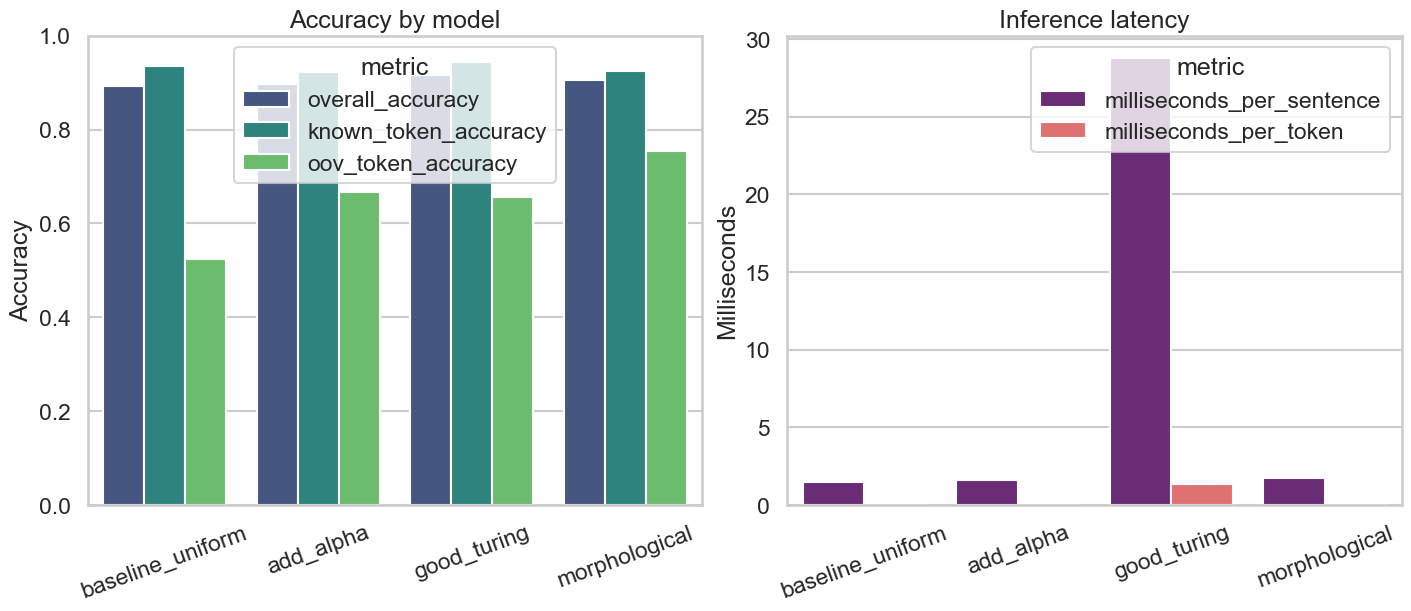

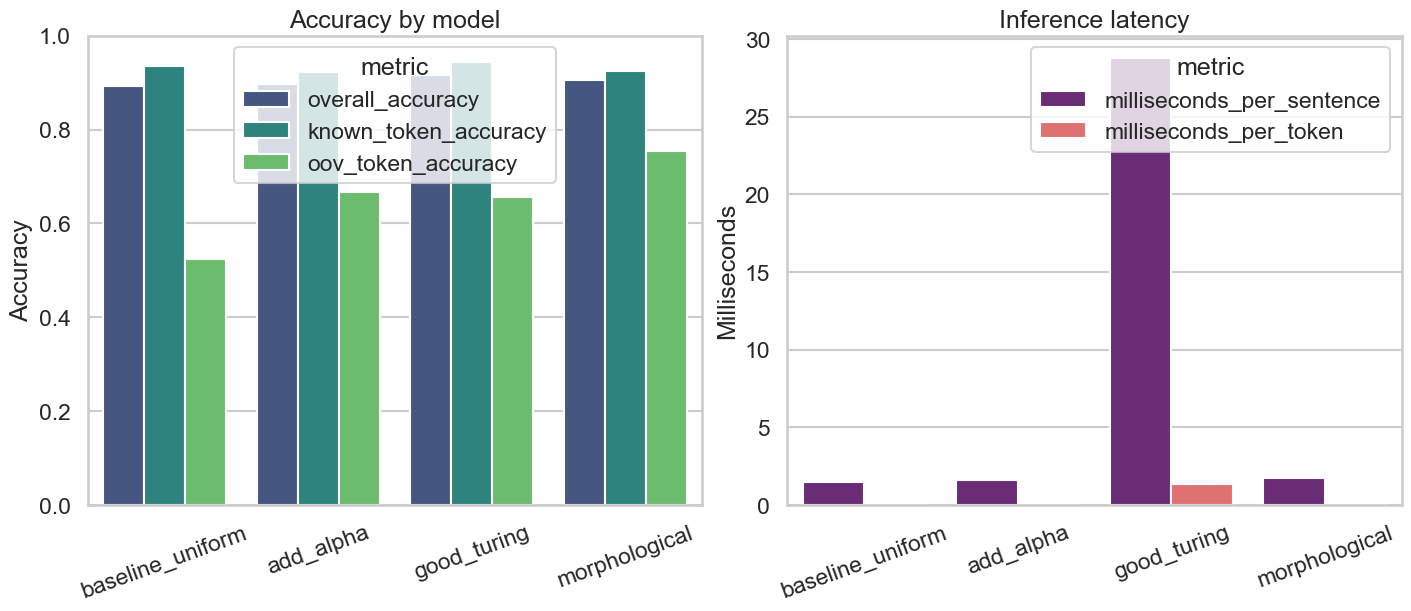

In [17]:
figure = plot_benchmark_results(benchmark_results)
figure

## Export a LaTeX Table for the Paper

In [18]:
latex_table = results_to_latex(benchmark_results)
print(latex_table)

\begin{tabular}{lrrrrrrrrr}
\toprule
model_name & overall_accuracy & known_token_accuracy & oov_token_accuracy & total_tokens & known_tokens & oov_tokens & decode_seconds & milliseconds_per_sentence & milliseconds_per_token \\
\midrule
baseline_uniform & 0.8936 & 0.9352 & 0.5235 & 10755 & 9670 & 1085 & 0.7470 & 1.4939 & 0.0695 \\
add_alpha & 0.8970 & 0.9229 & 0.6664 & 10755 & 9670 & 1085 & 0.7956 & 1.5912 & 0.0740 \\
good_turing & 0.9158 & 0.9448 & 0.6571 & 10755 & 9670 & 1085 & 14.3916 & 28.7831 & 1.3381 \\
morphological & 0.9066 & 0.9237 & 0.7539 & 10755 & 9670 & 1085 & 0.8544 & 1.7088 & 0.0794 \\
\bottomrule
\end{tabular}



## Save and Reload the Split for Reproducibility

Persist the exact train/test split and vocabulary to JSON so later experiments can reuse identical data.

In [19]:
split_path = loader.save_oov_split("artifacts/brown_oov_split.json", train_sents, test_sents, train_vocab)

reloaded_train_sents, reloaded_test_sents, reloaded_train_vocab = CorpusDataLoader.load_oov_split(split_path)

print(f"Saved split to: {split_path}")
print(f"Reloaded train sentences match: {reloaded_train_sents == train_sents}")
print(f"Reloaded vocabulary matches: {reloaded_train_vocab == train_vocab}")

Saved split to: artifacts\brown_oov_split.json
Reloaded train sentences match: True
Reloaded vocabulary matches: True


## Conclusion

This notebook reproduced the paper's controlled comparison: identical training/testing data, tag set, transition model, and Viterbi decoder across all four OOV strategies, varying only the emission handling for unknown words. The `morphological` strategy's OOV accuracy relative to `baseline_uniform`, `add_alpha`, and `good_turing` is the primary evidence for the paper's hypothesis, with per-sentence/per-token latency reported as the secondary computational-cost metric.